# AFC Lab — Fatigue Detection v11 (Tier 1: long window + per-subject z-score + engineered features)

PhysioNet (Empatica E4, AEROBIC + ANAEROBIC) **только**. Никаких других датасетов.

## Что меняется относительно v8.x

| Компонент | v8.x | **v11 (Tier 1)** |
|---|---|---|
| Окно | 5 с / stride 5 с (target 100) | **30 с / stride 15 с (target 300)** |
| Нормализация | глобальный StandardScaler | **per-subject z-score** (median/MAD) |
| 3-я ветка | stress profile (per-subject, 13 фич) | **HRV/IMU engineered features (per-window, ~14 фич)** |
| Регуляризация | SE + FiLM + R-Drop + SWA + Mixup | Focal + Cosine + Dropout ↑ + **Label Smooth + Mixup** |

## Гипотеза Tier 1

Усталость — динамика на минутах. На 5-сек окне HRV-паттерны и тренд EDA не успевают проявиться → информационный потолок 0.82. Длинное окно + ручные физиологические фичи (RMSSD, SDNN, SMA, jerk, …) дают модели сигнал, который CNN не выучит на 23K окнах.


In [578]:
# ── 1. Imports ──
import os, sys, random
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.interpolate import interp1d, CubicSpline
from scipy.signal import resample as sp_resample, find_peaks, welch

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve,
    auc, roc_curve,
)

sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

SEED = 4544655
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)
print(f"Seed: {SEED}")


PyTorch: 2.10.0+cu130, CUDA: True
Device: cuda
Seed: 4544655


## 2. CONFIG v11

- `window_sec=30`, `stride_sec=15`, `target_len=300` (≈10 Hz эффективно)
- `eng_dim=14` — HRV (BVP/HR), EDA, TEMP, IMU инженерные фичи на каждое окно
- Per-subject z-score: median/MAD по каналам IMU и Physio внутри субъекта
- **Anti-overfit**: stride 5→15 (overlap 83%→50%), dropout ↑, label_smoothing=0.1, mixup_alpha=0.3


In [579]:
CONFIG = {
    # --- Data / windowing ---
    'window_sec':  30.0,
    'stride_sec':  20.0,   # was 5.0 → overlap 83%→50%, reduces near-duplicate samples
    'target_len':  300,
    'fatigue_ratio': 0.7,

    # --- Training ---
    'batch_size':  8,  # was 32, reduced to prevent OOM with longer window
    'epochs':      80,
    'lr':          6e-5,  # was 3e-4, reduced for more stable training with longer window
    'weight_decay': 1e-2,  # was 4e-2, reduced to prevent over-regularization with longer window
    'patience':    10,
    'min_delta':   1e-4,
    'mixup_alpha': 0.1,    # Mixup regularization (0 = off) was 0.2

    # --- IMU encoder (длинное окно → большие kernels) ---
    'imu_channels':       6,
    'encoder_channels':   12,
    'encoder_dropout':    0.4,  # was 0.55
    'kernel_sizes':       [16, 8, 4, 2], # WAS  [21, 13, 8, 4]
    'attention_heads':    4,

    # --- Physio encoder ---
    'physio_channels':         4,
    'physio_encoder_channels': 8,

    # --- Engineered features (3-я ветка) ---
    'eng_dim':     14,
    'eng_hidden':  8,
    'eng_out':     16,
    'eng_dropout': 0.45,  # was 0.3

    # --- Classifier ---
    'classifier_dropout': 0.45,  # was 0.25

    # --- Loss / eval ---
    'focal_gamma':  3.1,  # was 2.1, increased to focus more on hard samples
    'label_smoothing': 0.15,   # prevents overconfidence
    'tta_n':       5,
    'min_precision_for_recall': 0.25,
}

_feat = CONFIG['encoder_channels'] + CONFIG['physio_encoder_channels'] + CONFIG['eng_out']
print('CONFIG v11 (Tier 1):')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')
print(f"\n  feat_dim = {CONFIG['encoder_channels']}(IMU) + "
      f"{CONFIG['physio_encoder_channels']}(Physio) + "
      f"{CONFIG['eng_out']}(EngFeat) = {_feat}")


CONFIG v11 (Tier 1):
  window_sec: 30.0
  stride_sec: 20.0
  target_len: 300
  fatigue_ratio: 0.7
  batch_size: 8
  epochs: 80
  lr: 6e-05
  weight_decay: 0.01
  patience: 10
  min_delta: 0.0001
  mixup_alpha: 0.1
  imu_channels: 6
  encoder_channels: 12
  encoder_dropout: 0.4
  kernel_sizes: [16, 8, 4, 2]
  attention_heads: 4
  physio_channels: 4
  physio_encoder_channels: 8
  eng_dim: 14
  eng_hidden: 8
  eng_out: 16
  eng_dropout: 0.45
  classifier_dropout: 0.45
  focal_gamma: 3.1
  label_smoothing: 0.15
  tta_n: 5
  min_precision_for_recall: 0.25

  feat_dim = 12(IMU) + 8(Physio) + 16(EngFeat) = 36


## 3. Загрузка PhysioNet (длинное окно из raw)

Грузим AEROBIC + ANAEROBIC напрямую из raw Empatica E4 CSV с **окном 30 с / stride 5 с**.
Не используем готовый `composite_full.npz` (он на 5-сек окне).


In [580]:
# ── Project root & paths ──
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(f"Marker '{marker}' not found from {os.getcwd()}")

PROJECT_ROOT = find_project_root('config.yaml')
PHYSIONET_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1' / 'Wearable_Dataset'
RESULTS_DIR = (PROJECT_ROOT / 'results_v11_window_physio').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'PhysioNet:    {PHYSIONET_ROOT}')
print(f'Results:      {RESULTS_DIR}')
print(f'AEROBIC exists:   {(PHYSIONET_ROOT / "AEROBIC").exists()}')
print(f'ANAEROBIC exists: {(PHYSIONET_ROOT / "ANAEROBIC").exists()}')


Project root: D:\Github\afc_lab
PhysioNet:    D:\Github\afc_lab\data\raw\wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1\Wearable_Dataset
Results:      D:\Github\afc_lab\results_v11_window_physio
AEROBIC exists:   True
ANAEROBIC exists: True


In [581]:
# ── Empatica E4 loaders ──
PHYSIONET_EXCLUDE = {'AEROBIC': {'S12'}, 'ANAEROBIC': set()}

def load_empatica_csv(filepath: Path):
    with open(filepath, 'r') as f:
        header = f.readline().strip()
        fs_line = f.readline().strip()
    start_str = header.split(',')[0].strip()
    try:
        start_time = datetime.strptime(start_str, '%Y-%m-%d %H:%M:%S')
    except ValueError:
        start_time = datetime.utcfromtimestamp(float(start_str))
    fs = float(fs_line.split(',')[0].strip())
    data = pd.read_csv(filepath, header=None, skiprows=2).values.astype(np.float32)
    return start_time, fs, data


def load_tags(filepath: Path):
    tags = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                tags.append(datetime.strptime(line, '%Y-%m-%d %H:%M:%S'))
            except ValueError:
                try:
                    tags.append(datetime.utcfromtimestamp(float(line)))
                except Exception:
                    continue
    return tags


def resample_signal(x: np.ndarray, target_len: int) -> np.ndarray:
    if len(x) == target_len:
        return x.astype(np.float32)
    if len(x) < 2:
        return np.zeros(target_len, dtype=np.float32)
    x_old = np.linspace(0, 1, len(x))
    x_new = np.linspace(0, 1, target_len)
    return interp1d(x_old, x, kind='linear', fill_value='extrapolate')(x_new).astype(np.float32)


def assign_fatigue_labels(centers_sec, tags_sec, fatigue_ratio=0.5):
    n = len(centers_sec)
    labels = np.zeros(n, dtype=np.int8)
    if len(tags_sec) >= 2:
        proto_start, proto_end = tags_sec[0], tags_sec[-1]
        if proto_end > proto_start:
            thr = proto_start + (proto_end - proto_start) * (1 - fatigue_ratio)
            labels[centers_sec >= thr] = 1
            return labels
    labels[n // 2:] = 1
    return labels


print('✅ Loaders ready')


✅ Loaders ready


In [582]:
# ── Engineered features (HRV / Physio / IMU) per window ──
# Считаем НА RAW сигналах (с их fs), это точнее, чем на ресемплированных.

ENG_FEATURE_NAMES = [
    'hr_mean', 'hr_std', 'hr_slope',
    'bvp_pp_amp', 'bvp_zc_rate',
    'eda_mean', 'eda_std', 'eda_slope',
    'temp_mean', 'temp_slope',
    'acc_sma', 'acc_mag_std', 'acc_jerk_std', 'acc_dom_freq',
]
assert len(ENG_FEATURE_NAMES) == 14


def _slope(y):
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y), dtype=np.float64)
    y = y.astype(np.float64)
    sx = x.mean(); sy = y.mean()
    num = ((x - sx) * (y - sy)).sum()
    den = ((x - sx) ** 2).sum() + 1e-9
    return float(num / den)


def _zero_cross_rate(x):
    x = x - np.mean(x)
    sgn = np.sign(x)
    return float(((sgn[:-1] * sgn[1:]) < 0).mean())


def _dominant_freq(sig, fs):
    if len(sig) < 8:
        return 0.0
    nperseg = min(len(sig), 256)
    f, p = welch(sig - np.mean(sig), fs=fs, nperseg=nperseg)
    if len(p) == 0:
        return 0.0
    return float(f[np.argmax(p)])


def compute_engineered_features(acc_seg, fs_acc,
                                bvp_seg, fs_bvp,
                                eda_seg, fs_eda,
                                temp_seg, fs_temp,
                                hr_seg, fs_hr) -> np.ndarray:
    feat = np.zeros(14, dtype=np.float32)
    # HR
    if len(hr_seg) > 1:
        h = hr_seg.flatten()
        h = np.where(np.isfinite(h), h, np.nanmedian(h) if np.isfinite(np.nanmedian(h)) else 0.0)
        feat[0] = float(np.mean(h))
        feat[1] = float(np.std(h))
        feat[2] = _slope(h)
    # BVP
    if len(bvp_seg) > 1:
        b = bvp_seg.flatten()
        # peak-to-peak amplitude as proxy for pulse magnitude variability
        try:
            peaks, _ = find_peaks(b, distance=max(1, int(fs_bvp * 0.4)))
            troughs, _ = find_peaks(-b, distance=max(1, int(fs_bvp * 0.4)))
            if len(peaks) > 0 and len(troughs) > 0:
                m = min(len(peaks), len(troughs))
                feat[3] = float(np.mean(np.abs(b[peaks[:m]] - b[troughs[:m]])))
        except Exception:
            feat[3] = 0.0
        feat[4] = _zero_cross_rate(b)
    # EDA
    if len(eda_seg) > 1:
        e = eda_seg.flatten()
        feat[5] = float(np.mean(e))
        feat[6] = float(np.std(e))
        feat[7] = _slope(e)
    # TEMP
    if len(temp_seg) > 1:
        t = temp_seg.flatten()
        feat[8] = float(np.mean(t))
        feat[9] = _slope(t)
    # IMU (ACC)
    if len(acc_seg) > 1 and acc_seg.ndim == 2 and acc_seg.shape[1] >= 3:
        a = acc_seg[:, :3].astype(np.float64)
        mag = np.linalg.norm(a, axis=1)
        feat[10] = float(np.mean(np.abs(a)))                 # SMA proxy
        feat[11] = float(np.std(mag))
        if len(mag) > 2:
            jerk = np.diff(mag) * fs_acc
            feat[12] = float(np.std(jerk))
        feat[13] = _dominant_freq(mag, fs_acc)
    return feat


print(f'✅ Engineered features: {len(ENG_FEATURE_NAMES)} per window')
print(f'   {ENG_FEATURE_NAMES}')


✅ Engineered features: 14 per window
   ['hr_mean', 'hr_std', 'hr_slope', 'bvp_pp_amp', 'bvp_zc_rate', 'eda_mean', 'eda_std', 'eda_slope', 'temp_mean', 'temp_slope', 'acc_sma', 'acc_mag_std', 'acc_jerk_std', 'acc_dom_freq']


In [583]:
# ── Per-subject window extraction (long window) ──

def extract_subject_windows(subj_dir: Path, window_sec: float, stride_sec: float,
                             target_len: int, fatigue_ratio: float):
    acc_p = subj_dir / 'ACC.csv'
    if not acc_p.exists():
        return None
    start_acc, fs_acc, acc_data = load_empatica_csv(acc_p)

    def _maybe(path, default_fs):
        if path.exists():
            _, fs, d = load_empatica_csv(path)
            return fs, d
        return default_fs, np.empty(0, dtype=np.float32)

    fs_bvp,  bvp_data  = _maybe(subj_dir / 'BVP.csv',  64.0)
    fs_eda,  eda_data  = _maybe(subj_dir / 'EDA.csv',   4.0)
    fs_temp, temp_data = _maybe(subj_dir / 'TEMP.csv',  4.0)
    fs_hr,   hr_data   = _maybe(subj_dir / 'HR.csv',    1.0)

    tags_p = subj_dir / 'tags.csv'
    tags = load_tags(tags_p) if tags_p.exists() else []
    tags_sec = np.array([(t - start_acc).total_seconds() for t in tags])
    tags_sec = tags_sec[tags_sec >= 0]

    durations = []
    for d, fs in [(acc_data, fs_acc), (bvp_data, fs_bvp), (eda_data, fs_eda),
                  (temp_data, fs_temp), (hr_data, fs_hr)]:
        if len(d) > 0:
            durations.append(len(d) / fs)
    if not durations:
        return None
    total_sec = min(durations)
    starts = np.arange(0, total_sec - window_sec + 1e-6, stride_sec)
    n = len(starts)
    if n == 0:
        return None

    X_imu = np.zeros((n, target_len, 6), dtype=np.float32)
    X_physio = np.zeros((n, target_len, 4), dtype=np.float32)
    X_eng = np.zeros((n, len(ENG_FEATURE_NAMES)), dtype=np.float32)
    centers = starts + window_sec / 2.0

    for w, t0 in enumerate(starts):
        t1 = t0 + window_sec
        # ACC raw segment
        i0, i1 = int(t0 * fs_acc), min(int(t1 * fs_acc), len(acc_data))
        acc_seg = acc_data[i0:i1] if i1 > i0 else np.empty((0, 3), dtype=np.float32)
        if acc_seg.ndim == 1:
            acc_seg = acc_seg.reshape(-1, 1)
        for c in range(min(acc_seg.shape[1], 3)):
            if acc_seg.shape[0] > 0:
                X_imu[w, :, c] = resample_signal(acc_seg[:, c], target_len)
        # BVP
        i0, i1 = int(t0 * fs_bvp), min(int(t1 * fs_bvp), len(bvp_data))
        bvp_seg = bvp_data[i0:i1].flatten() if i1 > i0 else np.empty(0, dtype=np.float32)
        if len(bvp_seg) > 0:
            X_physio[w, :, 0] = resample_signal(bvp_seg, target_len)
        # EDA
        i0, i1 = int(t0 * fs_eda), min(int(t1 * fs_eda), len(eda_data))
        eda_seg = eda_data[i0:i1].flatten() if i1 > i0 else np.empty(0, dtype=np.float32)
        if len(eda_seg) > 0:
            X_physio[w, :, 1] = resample_signal(eda_seg, target_len)
        # TEMP
        i0, i1 = int(t0 * fs_temp), min(int(t1 * fs_temp), len(temp_data))
        temp_seg = temp_data[i0:i1].flatten() if i1 > i0 else np.empty(0, dtype=np.float32)
        if len(temp_seg) > 0:
            X_physio[w, :, 2] = resample_signal(temp_seg, target_len)
        # HR
        i0, i1 = int(t0 * fs_hr), min(int(t1 * fs_hr), len(hr_data))
        hr_seg = hr_data[i0:i1].flatten() if i1 > i0 else np.empty(0, dtype=np.float32)
        if len(hr_seg) > 0:
            X_physio[w, :, 3] = resample_signal(hr_seg, target_len)
        # Engineered features on RAW segments
        X_eng[w] = compute_engineered_features(
            acc_seg, fs_acc, bvp_seg, fs_bvp, eda_seg, fs_eda,
            temp_seg, fs_temp, hr_seg, fs_hr)

    y = assign_fatigue_labels(centers, tags_sec, fatigue_ratio=fatigue_ratio)
    return X_imu, X_physio, X_eng, y


print('✅ extract_subject_windows ready')


✅ extract_subject_windows ready


In [584]:
# ── Walk PhysioNet AEROBIC + ANAEROBIC ──
all_imu, all_physio, all_eng, all_y, all_pids = [], [], [], [], []

for protocol in ['AEROBIC', 'ANAEROBIC']:
    proto_dir = PHYSIONET_ROOT / protocol
    if not proto_dir.exists():
        print(f'⚠️ missing {proto_dir}')
        continue
    excl = PHYSIONET_EXCLUDE.get(protocol, set())
    subj_dirs = sorted([d for d in proto_dir.iterdir() if d.is_dir()])
    print(f'\n📁 {protocol}: {len(subj_dirs)} subjects')
    for subj_dir in tqdm(subj_dirs, desc=protocol):
        base_id = subj_dir.name.split('_')[0]
        if base_id in excl:
            continue
        try:
            res = extract_subject_windows(
                subj_dir,
                window_sec=CONFIG['window_sec'],
                stride_sec=CONFIG['stride_sec'],
                target_len=CONFIG['target_len'],
                fatigue_ratio=CONFIG['fatigue_ratio'],
            )
        except Exception as e:
            print(f'   ❌ {subj_dir.name}: {e}')
            continue
        if res is None:
            continue
        Xi, Xp, Xe, y = res
        all_imu.append(Xi); all_physio.append(Xp); all_eng.append(Xe); all_y.append(y)
        pid = f'physionet_{base_id}'
        all_pids.extend([pid] * len(y))

X_imu_raw    = np.concatenate(all_imu, axis=0).astype(np.float32)
X_physio_raw = np.concatenate(all_physio, axis=0).astype(np.float32)
X_eng_raw    = np.concatenate(all_eng, axis=0).astype(np.float32)
y_all        = np.concatenate(all_y, axis=0).astype(np.int64)
subjects     = np.array(all_pids)

# Replace NaN/Inf
X_imu_raw    = np.nan_to_num(X_imu_raw,    nan=0.0, posinf=0.0, neginf=0.0)
X_physio_raw = np.nan_to_num(X_physio_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_eng_raw    = np.nan_to_num(X_eng_raw,    nan=0.0, posinf=0.0, neginf=0.0)

print(f'\n✅ Loaded:')
print(f'   X_imu:    {X_imu_raw.shape}')
print(f'   X_physio: {X_physio_raw.shape}')
print(f'   X_eng:    {X_eng_raw.shape}')
print(f'   y:        {y_all.shape}  ({y_all.mean():.1%} positive)')
print(f'   subjects: {len(np.unique(subjects))}')



📁 AEROBIC: 31 subjects


AEROBIC:   0%|          | 0/31 [00:00<?, ?it/s]

AEROBIC: 100%|██████████| 31/31 [00:05<00:00,  5.60it/s]



📁 ANAEROBIC: 32 subjects


ANAEROBIC: 100%|██████████| 32/32 [00:04<00:00,  7.78it/s]



✅ Loaded:
   X_imu:    (5700, 300, 6)
   X_physio: (5700, 300, 4)
   X_eng:    (5700, 14)
   y:        (5700,)  (57.0% positive)
   subjects: 31


In [585]:
# ── Per-subject z-score normalization (median / MAD, robust) ──

def per_subject_robust_zscore(X: np.ndarray, pids: np.ndarray) -> np.ndarray:
    out = X.copy().astype(np.float32)
    for pid in np.unique(pids):
        mask = pids == pid
        for c in range(out.shape[2]):
            ch = out[mask, :, c]
            med = np.median(ch)
            mad = np.median(np.abs(ch - med)) * 1.4826 + 1e-6
            out[mask, :, c] = (ch - med) / mad
    return out


print('🔧 Per-subject z-score (median/MAD)…')
X_imu    = per_subject_robust_zscore(X_imu_raw,    subjects)
X_physio = per_subject_robust_zscore(X_physio_raw, subjects)

# Engineered features: global z-score (handcrafted features have meaningful units across subjects)
eng_mean = X_eng_raw.mean(axis=0)
eng_std  = X_eng_raw.std(axis=0) + 1e-6
X_eng    = ((X_eng_raw - eng_mean) / eng_std).astype(np.float32)

has_physio = np.ones(len(y_all), dtype=bool)  # all PhysioNet → all True

print(f'   X_imu:    mean={X_imu.mean():.3f}, std={X_imu.std():.3f}')
print(f'   X_physio: mean={X_physio.mean():.3f}, std={X_physio.std():.3f}')
print(f'   X_eng:    mean={X_eng.mean():.3f}, std={X_eng.std():.3f}')


🔧 Per-subject z-score (median/MAD)…
   X_imu:    mean=-0.015, std=1.670
   X_physio: mean=1.310, std=15.316
   X_eng:    mean=-0.000, std=1.000


DATASET v11 (PhysioNet, long window 30s/5s)
  Окон: 5700, субъектов: 31
  Positive (fatigue): 3251/5700 (57.0%)
  Окон/субъект: median=159, min=55, max=279


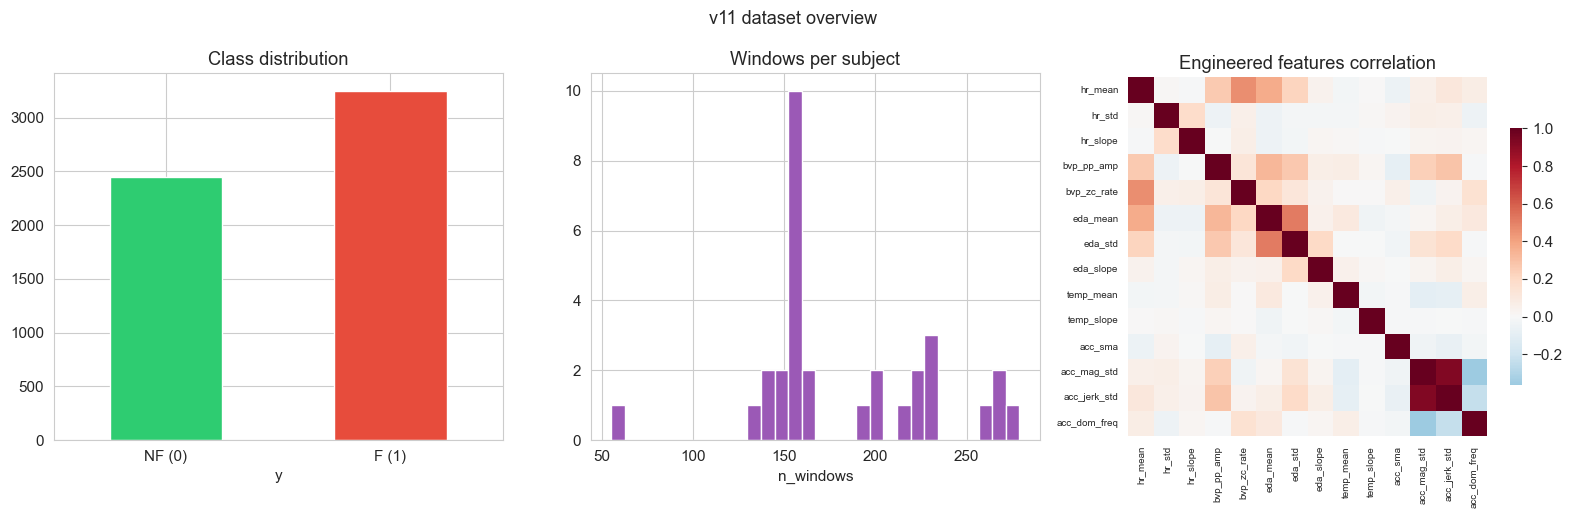

In [586]:
# ── Stats + plots ──
df_meta = pd.DataFrame({'sid': subjects, 'y': y_all})
n = len(y_all); pos = y_all.sum()
n_subj = len(np.unique(subjects))
print('=' * 60)
print('DATASET v11 (PhysioNet, long window 30s/5s)')
print('=' * 60)
print(f'  Окон: {n}, субъектов: {n_subj}')
print(f'  Positive (fatigue): {pos}/{n} ({pos/n:.1%})')
counts = df_meta.groupby('sid').size()
print(f'  Окон/субъект: median={counts.median():.0f}, min={counts.min()}, max={counts.max()}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df_meta['y'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class distribution'); axes[0].set_xticklabels(['NF (0)', 'F (1)'], rotation=0)

counts.hist(ax=axes[1], bins=30, color='#9b59b6', edgecolor='white')
axes[1].set_title('Windows per subject'); axes[1].set_xlabel('n_windows')

eng_df = pd.DataFrame(X_eng, columns=ENG_FEATURE_NAMES)
sns.heatmap(eng_df.corr(), ax=axes[2], cmap='RdBu_r', center=0, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.7})
axes[2].set_title('Engineered features correlation')
axes[2].tick_params(axis='x', labelsize=7); axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle('v11 dataset overview', fontsize=13)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'dataset_overview_v11.png', dpi=150); plt.show()


## 4. Subject-level split (60/20/20)


In [587]:
def create_subject_split(subjects, y, test_size=0.2, val_size=0.2, seed=SEED):
    uniq = np.unique(subjects)
    sid_tv, sid_te = train_test_split(uniq, test_size=test_size, random_state=seed)
    sid_tr, sid_va = train_test_split(
        sid_tv, test_size=val_size / (1.0 - test_size), random_state=seed)
    tr = np.where(np.isin(subjects, sid_tr))[0]
    va = np.where(np.isin(subjects, sid_va))[0]
    te = np.where(np.isin(subjects, sid_te))[0]
    for name, idx in [('Train', tr), ('Val', va), ('Test', te)]:
        if len(np.unique(y[idx])) < 2:
            raise ValueError(f'{name} has only one class')
    return tr, va, te

train_idx, val_idx, test_idx = create_subject_split(subjects, y_all)
for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    cls = np.bincount(y_all[idx], minlength=2)
    print(f'{name:5s}: {len(idx):>5} wins, {len(np.unique(subjects[idx]))} subj '
          f'| 0→{cls[0]}, 1→{cls[1]} ({y_all[idx].mean():.1%} pos)')


Train:  3238 wins, 18 subj | 0→1374, 1→1864 (57.6% pos)
Val  :  1109 wins, 6 subj | 0→462, 1→647 (58.3% pos)
Test :  1353 wins, 7 subj | 0→613, 1→740 (54.7% pos)


## 5. Augmentation + Dataset (5-tuple: imu, physio, has_physio, eng, y)


In [588]:
# ── Augmentation (simplified) ──
def add_noise(x, sigma=0.05):
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)

def magnitude_scale(x, lo=0.8, hi=1.2):
    return x * np.random.uniform(lo, hi, (1, x.shape[1])).astype(x.dtype)

def time_warp(x, sigma=0.2, knots=4):
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    fn = CubicSpline(tt, warp)
    t_o = np.arange(T)
    t_w = np.clip(t_o + fn(t_o), 0, T - 1)
    return np.stack([CubicSpline(t_o, x[:, c])(t_w) for c in range(C)], axis=-1).astype(x.dtype)

def channel_dropout(x, p=0.15):
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x

def imu_rotate(x, max_deg=15.0):
    theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
    n = np.random.randn(3); n /= (np.linalg.norm(n) + 1e-8)
    K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K
    x = x.copy()
    x[:, :3] = x[:, :3] @ R.T
    return x.astype(np.float32)


def augment_imu_physio(x_imu, x_physio):
    if np.random.rand() < 0.7: x_imu = add_noise(x_imu, np.random.uniform(0.03, 0.08))
    if np.random.rand() < 0.5: x_imu = magnitude_scale(x_imu, 0.8, 1.2)
    if np.random.rand() < 0.4: x_imu = time_warp(x_imu, sigma=0.2)
    if np.random.rand() < 0.4: x_imu = imu_rotate(x_imu, 15.0)
    x_imu = channel_dropout(x_imu, 0.15)

    if np.random.rand() < 0.5: x_physio = add_noise(x_physio, np.random.uniform(0.02, 0.05))
    if np.random.rand() < 0.3: x_physio = magnitude_scale(x_physio, 0.9, 1.1)
    return x_imu, x_physio


class FatigueDataset(Dataset):
    # Returns (x_imu, x_physio, has_physio, eng_feat, y)
    def __init__(self, X_imu, X_physio, X_eng, y, has_physio, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.X_eng = X_eng.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        xi, xp = self.X_imu[idx].copy(), self.X_physio[idx].copy()
        if self.augment:
            xi, xp = augment_imu_physio(xi, xp)
        return (torch.from_numpy(xi).float(),
                torch.from_numpy(xp).float(),
                torch.tensor(self.has_physio[idx], dtype=torch.float32),
                torch.from_numpy(self.X_eng[idx]).float(),
                torch.tensor(self.y[idx], dtype=torch.float32))


print('✅ Augmentation + Dataset ready')


✅ Augmentation + Dataset ready


## 6. Model — IMU-CNN + Physio-CNN + EngFeat-MLP

```
IMU (B, T, 6)   →  4× Conv1D + MultiHeadTemporalAttention   → (B, enc_ch)
Physio (B, T, 4) → 3× Conv1D + GAP                          → (B, physio_ch)
EngFeat (B, 14) → MLP(32→16)                                → (B, eng_out)
                                ↓
              Concat → LayerNorm → MLP → 1 logit
```


In [589]:
class MultiHeadTemporalAttention(nn.Module):
    def __init__(self, channels, n_heads=4):
        super().__init__()
        assert channels % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = channels // n_heads
        self.score = nn.Conv1d(channels, n_heads, kernel_size=1)

    def forward(self, x):  # x: (B, C, T)
        B, C, T = x.shape
        w = torch.softmax(self.score(x), dim=-1)
        x_h = x.view(B, self.n_heads, self.head_dim, T)
        return (x_h * w.unsqueeze(2)).sum(-1).reshape(B, C)


class IMUEncoder(nn.Module):
    def __init__(self, in_ch, out_ch, dropout, kernel_sizes, n_heads=4):
        super().__init__()
        k1, k2, k3, k4 = kernel_sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k1, padding=k1 // 2),
            nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, k2, padding=k2 // 2),
            nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.conv3 = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, k3, padding=k3 // 2),
            nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.conv4 = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, k4, padding=k4 // 2),
            nn.BatchNorm1d(out_ch), nn.ReLU(True))
        self.attn = MultiHeadTemporalAttention(out_ch, n_heads)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x); x = self.conv4(x)
        return self.attn(x)


class PhysioEncoder(nn.Module):
    def __init__(self, in_ch, out_ch, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=11, padding=5),
            nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2), nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2), nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_ch), nn.ReLU(True),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.net(x.transpose(1, 2)).squeeze(-1)


class EngFeatMLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.LayerNorm(out_dim), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class FatigueWristNetV11(nn.Module):
    # 3-branch: IMU CNN + Physio CNN + Engineered features MLP
    def __init__(self, cfg):
        super().__init__()
        enc, phys, eng_o = (cfg['encoder_channels'],
                             cfg['physio_encoder_channels'],
                             cfg['eng_out'])
        self.imu_encoder = IMUEncoder(
            cfg['imu_channels'], enc, cfg['encoder_dropout'],
            cfg['kernel_sizes'], n_heads=cfg['attention_heads'])
        self.physio_encoder = PhysioEncoder(
            cfg['physio_channels'], phys, cfg['encoder_dropout'])
        self.eng_mlp = EngFeatMLP(
            cfg['eng_dim'], cfg['eng_hidden'], eng_o, cfg['eng_dropout'])

        feat = enc + phys + eng_o
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat),
            nn.Linear(feat, feat), nn.GELU(), nn.Dropout(cfg['classifier_dropout']),
            nn.Linear(feat, feat // 2), nn.GELU(), nn.Dropout(cfg['classifier_dropout'] / 2),
            nn.Linear(feat // 2, 1),
        )

    def forward(self, x_imu, x_physio, has_physio, eng_feat):
        f_imu = self.imu_encoder(x_imu)
        f_phys = self.physio_encoder(x_physio)
        if has_physio is not None:
            f_phys = f_phys * has_physio.unsqueeze(-1)
        f_eng = self.eng_mlp(eng_feat)
        return self.classifier(torch.cat([f_imu, f_phys, f_eng], dim=1)).squeeze(-1)


_m = FatigueWristNetV11(CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in _m.parameters())
print(f'✅ FatigueWristNetV11: {n_params:,} params')
with torch.no_grad():
    out = _m(torch.randn(2, CONFIG['target_len'], 6).to(DEVICE),
             torch.randn(2, CONFIG['target_len'], 4).to(DEVICE),
             torch.ones(2).to(DEVICE),
             torch.randn(2, CONFIG['eng_dim']).to(DEVICE))
    print(f'   smoke test → {out.shape}')
del _m


✅ FatigueWristNetV11: 6,829 params
   smoke test → torch.Size([2])


## 7. Loss / Train / Validate / TTA


In [590]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.ls = label_smoothing

    def forward(self, logits, targets):
        if self.ls > 0:
            targets = targets * (1 - self.ls) + 0.5 * self.ls
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        return ((1 - p_t) ** self.gamma * bce).mean()


def compute_class_weights(y):
    w = np.zeros(len(y), dtype=np.float64)
    for c in [0, 1]:
        m = y == c
        if m.sum() > 0:
            w[m] = len(y) / (2 * m.sum())
    return w


def compute_pos_weight(y):
    pos = y.sum()
    return (len(y) - pos) / max(pos, 1)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, int)
    y_pred = (y_prob >= threshold).astype(int)
    out = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }
    if np.unique(y_true).size >= 2:
        out['roc_auc'] = roc_auc_score(y_true, y_prob)
        pr, rc, _ = precision_recall_curve(y_true, y_prob)
        out['pr_auc'] = auc(rc, pr)
    else:
        out['roc_auc'] = out['pr_auc'] = np.nan
    return out, y_pred


def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1


def find_recall_threshold(y_true, y_prob, min_precision=0.25):
    best_t, best_rec = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        prec = tp / (tp + fp + 1e-8); rec = tp / (tp + fn + 1e-8)
        if prec >= min_precision and rec > best_rec:
            best_rec, best_t = rec, float(t)
    return best_t, best_rec


class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, ema_alpha=0.3):
        self.patience = patience; self.min_delta = min_delta; self.alpha = ema_alpha
        self.best_score = -np.inf; self.counter = 0
        self.best_model = None; self._ema = None

    def smooth(self, s):
        self._ema = s if self._ema is None else self.alpha * s + (1 - self.alpha) * self._ema
        return self._ema

    def __call__(self, s, model):
        e = self.smooth(s)
        if e > self.best_score + self.min_delta:
            self.best_score = e; self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    @property
    def ema(self):
        return self._ema if self._ema is not None else 0.0


def train_epoch(model, loader, optimizer, criterion, device, mixup_alpha=0.0):
    model.train()
    total = 0.0
    for xi, xp, hp, eng, y in loader:
        xi, xp, hp, eng, y = (t.to(device) for t in (xi, xp, hp, eng, y))
        if mixup_alpha > 0 and np.random.rand() < 0.5:
            lam = float(np.random.beta(mixup_alpha, mixup_alpha))
            idx = torch.randperm(xi.size(0), device=device)
            xi  = lam * xi  + (1 - lam) * xi[idx]
            xp  = lam * xp  + (1 - lam) * xp[idx]
            eng = lam * eng + (1 - lam) * eng[idx]
            y   = lam * y   + (1 - lam) * y[idx]
        optimizer.zero_grad()
        logits = model(xi, xp, hp, eng)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    model.eval()
    total = 0.0; probs = []; labels = []
    with torch.no_grad():
        for xi, xp, hp, eng, y in loader:
            xi, xp, hp, eng, y = (t.to(device) for t in (xi, xp, hp, eng, y))
            logits = model(xi, xp, hp, eng)
            total += criterion(logits, y).item() * len(y)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(y.cpu().numpy())
    probs = np.array(probs, dtype=np.float32)
    labels = np.array(labels, dtype=int)
    metrics, _ = compute_metrics(labels, probs, threshold)
    if return_raw:
        return total / len(loader.dataset), metrics, labels, probs
    return total / len(loader.dataset), metrics


def predict_with_tta(model, X_imu, X_physio, X_eng, y, has_physio, device,
                     tta_n=5, batch_size=64):
    model.eval()
    def _infer(ds):
        ld = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        ps = []
        with torch.no_grad():
            for xi, xp, hp, eng, _ in ld:
                logits = model(xi.to(device), xp.to(device), hp.to(device), eng.to(device))
                ps.extend(torch.sigmoid(logits).cpu().numpy())
        return np.array(ps, dtype=np.float32)
    all_probs = [_infer(FatigueDataset(X_imu, X_physio, X_eng, y, has_physio, augment=False))]
    for _ in range(tta_n - 1):
        all_probs.append(_infer(FatigueDataset(X_imu, X_physio, X_eng, y, has_physio, augment=True)))
    return np.mean(all_probs, axis=0)


print('✅ Loss / train / validate / TTA ready')


✅ Loss / train / validate / TTA ready


## 8. Training


In [591]:
# ── Prep loaders ──
train_ds = FatigueDataset(X_imu[train_idx], X_physio[train_idx], X_eng[train_idx],
                          y_all[train_idx], has_physio[train_idx], augment=True)
val_ds   = FatigueDataset(X_imu[val_idx],   X_physio[val_idx],   X_eng[val_idx],
                          y_all[val_idx],   has_physio[val_idx])
test_ds  = FatigueDataset(X_imu[test_idx],  X_physio[test_idx],  X_eng[test_idx],
                          y_all[test_idx],  has_physio[test_idx])

sample_w = compute_class_weights(y_all[train_idx])
sampler = WeightedRandomSampler(torch.from_numpy(sample_w).double(),
                                 len(train_ds), replacement=True)
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

model = FatigueWristNetV11(CONFIG).to(DEVICE)
pw = compute_pos_weight(y_all[train_idx])
criterion = FocalLoss(gamma=CONFIG['focal_gamma'],
                      pos_weight=torch.tensor([pw]).to(DEVICE),
                      label_smoothing=CONFIG['label_smoothing'])
optimizer = optim.AdamW(model.parameters(),
                         lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

print(f"Model:     FatigueWristNetV11 ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"Loss:      Focal(γ={CONFIG['focal_gamma']}, pos_weight={pw:.2f})")
print(f"Optim:     AdamW(lr={CONFIG['lr']}, wd={CONFIG['weight_decay']})")
print(f"Sched:     CosineAnnealingLR(T_max={CONFIG['epochs']})")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")


Model:     FatigueWristNetV11 (6,829 params)
Loss:      Focal(γ=3.1, pos_weight=0.74)
Optim:     AdamW(lr=6e-05, wd=0.01)
Sched:     CosineAnnealingLR(T_max=80)
Train: 3238, Val: 1109, Test: 1353


In [592]:
# ── Training loop ──
print('=' * 65)
print('TRAINING v11 (Tier 1)')
print('=' * 65)

history = {'train_loss': [], 'val_loss': [],
           'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
           'val_f1_ema': [], 'lr': []}

best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE,
                             mixup_alpha=CONFIG['mixup_alpha'])
    val_loss, vm, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, return_raw=True)
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['val_f1'].append(vm['f1_macro']); history['val_auc'].append(vm.get('roc_auc', np.nan))
    history['val_pr_auc'].append(vm.get('pr_auc', np.nan))
    history['val_bal_acc'].append(vm['balanced_acc']); history['lr'].append(lr_now)

    stop = early_stopping(vm['f1_macro'], model)
    history['val_f1_ema'].append(early_stopping.ema)

    if vm['f1_macro'] > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = vm['f1_macro']; best_epoch = epoch + 1
        best_threshold, _ = find_best_threshold(val_labels, val_probs)
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': CONFIG,
            'best_threshold': best_threshold,
            'best_val_f1': best_val_f1,
            'roc_auc': vm.get('roc_auc', float('nan')),
        }, RESULTS_DIR / 'best_model_v11.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Ep {epoch+1:3d}/{CONFIG['epochs']} | "
              f"TrL {train_loss:.4f} | VaL {val_loss:.4f} | "
              f"F1 {vm['f1_macro']:.4f} (ema {early_stopping.ema:.4f}) | "
              f"AUC {vm.get('roc_auc', float('nan')):.4f} | LR {lr_now:.2e}")
    if stop:
        print(f'\nEarly stop @ epoch {epoch+1} (EMA F1={early_stopping.ema:.4f})')
        break

if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)
print(f'✅ Best epoch: {best_epoch}, val F1: {best_val_f1:.4f}, threshold: {best_threshold:.3f}')


TRAINING v11 (Tier 1)


Ep   1/80 | TrL 0.0690 | VaL 0.0670 | F1 0.3573 (ema 0.3573) | AUC 0.7356 | LR 6.00e-05
Ep   5/80 | TrL 0.0586 | VaL 0.0670 | F1 0.5255 (ema 0.4117) | AUC 0.8261 | LR 5.94e-05
Ep  10/80 | TrL 0.0542 | VaL 0.0573 | F1 0.6817 (ema 0.5827) | AUC 0.8473 | LR 5.78e-05
Ep  15/80 | TrL 0.0522 | VaL 0.0572 | F1 0.6893 (ema 0.6776) | AUC 0.8442 | LR 5.50e-05
Ep  20/80 | TrL 0.0512 | VaL 0.0532 | F1 0.7313 (ema 0.7208) | AUC 0.8745 | LR 5.14e-05
Ep  25/80 | TrL 0.0512 | VaL 0.0532 | F1 0.7832 (ema 0.7470) | AUC 0.8728 | LR 4.69e-05
Ep  30/80 | TrL 0.0533 | VaL 0.0554 | F1 0.7624 (ema 0.7597) | AUC 0.8568 | LR 4.18e-05
Ep  35/80 | TrL 0.0517 | VaL 0.0561 | F1 0.7480 (ema 0.7535) | AUC 0.8443 | LR 3.63e-05
Ep  40/80 | TrL 0.0499 | VaL 0.0544 | F1 0.7754 (ema 0.7496) | AUC 0.8588 | LR 3.05e-05

Early stop @ epoch 40 (EMA F1=0.7496)
✅ Best epoch: 25, val F1: 0.7832, threshold: 0.485


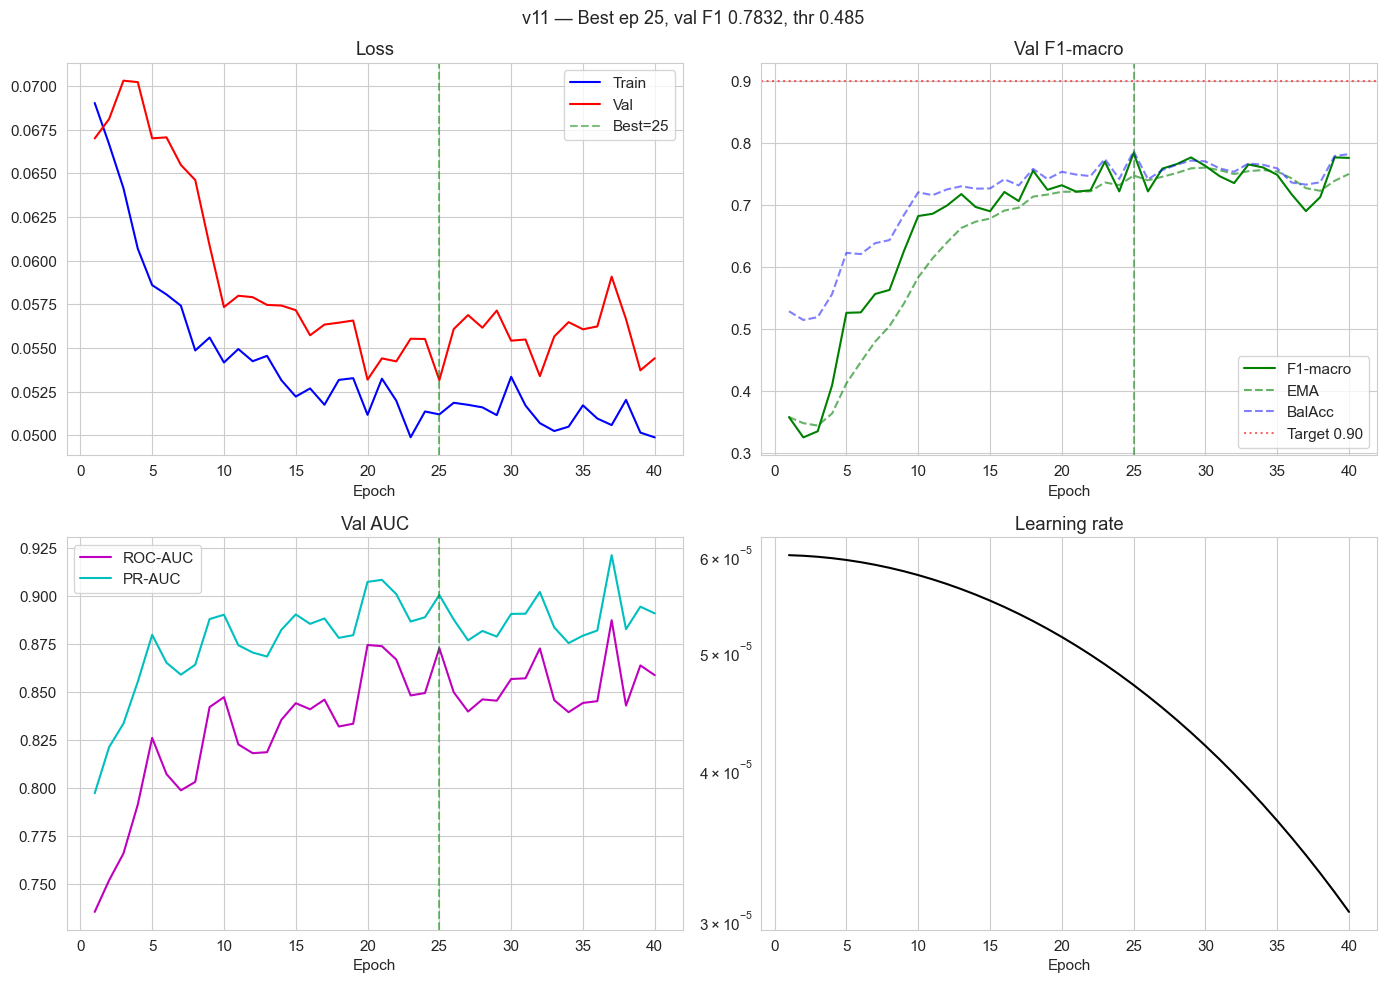

In [593]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ep = range(1, len(history['train_loss']) + 1)
    axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
    axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
    if best_epoch:
        axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best={best_epoch}')
    axes[0, 0].set_title('Loss'); axes[0, 0].legend(); axes[0, 0].set_xlabel('Epoch')

    axes[0, 1].plot(ep, history['val_f1'], 'g-', label='F1-macro')
    axes[0, 1].plot(ep, history['val_f1_ema'], 'g--', alpha=0.6, label='EMA')
    axes[0, 1].plot(ep, history['val_bal_acc'], 'b--', alpha=0.5, label='BalAcc')
    if best_epoch:
        axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    axes[0, 1].axhline(0.9, color='r', ls=':', alpha=0.6, label='Target 0.90')
    axes[0, 1].set_title('Val F1-macro'); axes[0, 1].legend(); axes[0, 1].set_xlabel('Epoch')

    axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
    axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
    if best_epoch:
        axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    axes[1, 0].set_title('Val AUC'); axes[1, 0].legend(); axes[1, 0].set_xlabel('Epoch')

    axes[1, 1].plot(ep, history['lr'], 'k-')
    axes[1, 1].set_title('Learning rate'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_yscale('log')

    plt.suptitle(f'v11 — Best ep {best_epoch}, val F1 {best_val_f1:.4f}, thr {best_threshold:.3f}',
                 fontsize=13)
    plt.tight_layout(); plt.savefig(RESULTS_DIR / 'training_history_v11.png', dpi=150); plt.show()

plot_training_history(history)


## 9. Test evaluation (TTA + thresholds)


In [594]:
print(f'Running TTA × {CONFIG["tta_n"]}…')
test_probs = predict_with_tta(
    model, X_imu[test_idx], X_physio[test_idx], X_eng[test_idx],
    y_all[test_idx], has_physio[test_idx], device=DEVICE,
    tta_n=CONFIG['tta_n'], batch_size=CONFIG['batch_size'])
test_labels = y_all[test_idx].astype(int)

m_val_thr,  preds_val_thr  = compute_metrics(test_labels, test_probs, best_threshold)
test_best_t, _              = find_best_threshold(test_labels, test_probs)
m_topt,     preds_topt      = compute_metrics(test_labels, test_probs, test_best_t)
rec_t, rec_v                = find_recall_threshold(test_labels, test_probs,
                                                     CONFIG['min_precision_for_recall'])
m_recall,   _               = compute_metrics(test_labels, test_probs, rec_t)

print('=' * 65)
print('TEST RESULTS v11 (Tier 1)')
print('=' * 65)
print(f'\n📊 Val threshold = {best_threshold:.3f}  [TTA × {CONFIG["tta_n"]}]:')
for k in ['f1_macro', 'roc_auc', 'pr_auc', 'balanced_acc']:
    print(f'   {k:13s}: {m_val_thr[k]:.4f}')
print(classification_report(test_labels, preds_val_thr,
                             target_names=['Normal', 'Fatigue'], zero_division=0))

print(f'📊 Test-optimal threshold = {test_best_t:.3f}  [upper bound]:')
print(f'   F1-macro: {m_topt["f1_macro"]:.4f} | BalAcc: {m_topt["balanced_acc"]:.4f}')
print(classification_report(test_labels, preds_topt,
                             target_names=['Normal', 'Fatigue'], zero_division=0))

print(f'📊 Recall-optimized threshold = {rec_t:.3f} (recall={rec_v:.3f}):')
print(f'   F1-macro: {m_recall["f1_macro"]:.4f} | BalAcc: {m_recall["balanced_acc"]:.4f}')


Running TTA × 5…
TEST RESULTS v11 (Tier 1)

📊 Val threshold = 0.485  [TTA × 5]:
   f1_macro     : 0.7557
   roc_auc      : 0.8374
   pr_auc       : 0.8725
   balanced_acc : 0.7570
              precision    recall  f1-score   support

      Normal       0.72      0.76      0.74       613
     Fatigue       0.79      0.76      0.77       740

    accuracy                           0.76      1353
   macro avg       0.76      0.76      0.76      1353
weighted avg       0.76      0.76      0.76      1353

📊 Test-optimal threshold = 0.485  [upper bound]:
   F1-macro: 0.7557 | BalAcc: 0.7570
              precision    recall  f1-score   support

      Normal       0.72      0.76      0.74       613
     Fatigue       0.79      0.76      0.77       740

    accuracy                           0.76      1353
   macro avg       0.76      0.76      0.76      1353
weighted avg       0.76      0.76      0.76      1353

📊 Recall-optimized threshold = 0.050 (recall=1.000):
   F1-macro: 0.3536 | BalAc

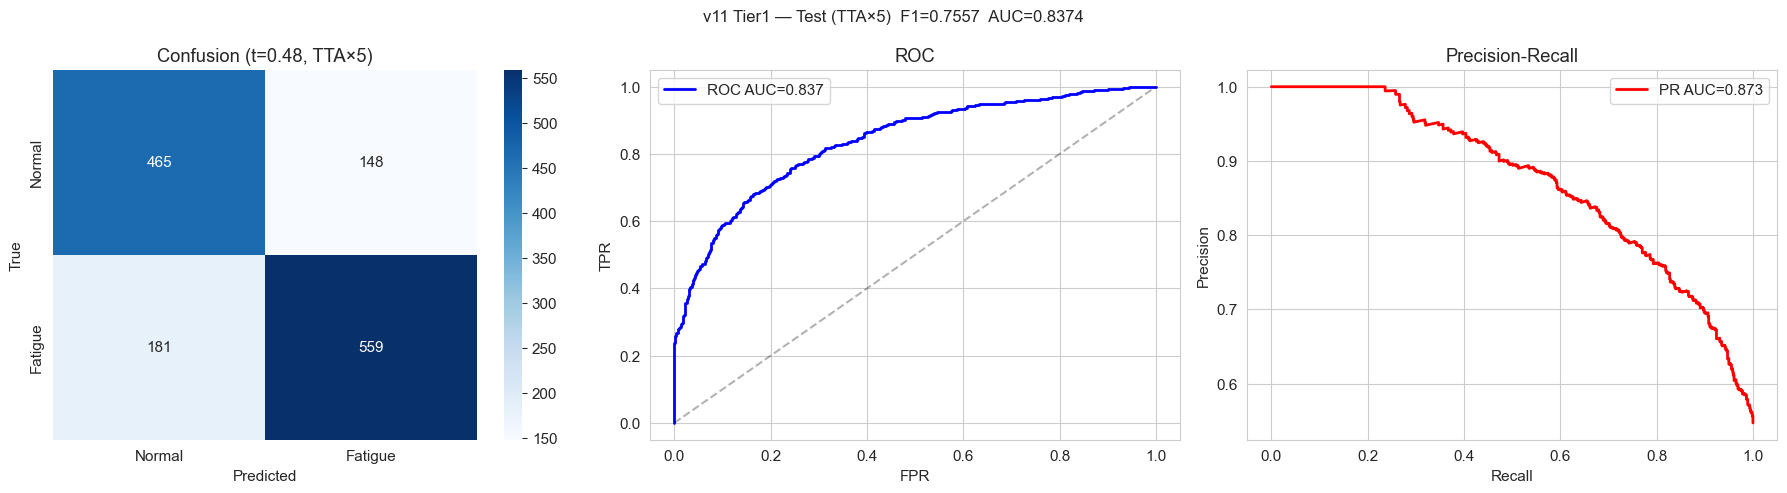

In [595]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(test_labels, preds_val_thr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fatigue'], yticklabels=['Normal', 'Fatigue'])
axes[0].set_title(f'Confusion (t={best_threshold:.2f}, TTA×{CONFIG["tta_n"]})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC AUC={m_val_thr["roc_auc"]:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3); axes[1].set_title('ROC')
axes[1].legend(); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')

pr, rc, _ = precision_recall_curve(test_labels, test_probs)
axes[2].plot(rc, pr, 'r-', lw=2, label=f'PR AUC={m_val_thr["pr_auc"]:.3f}')
axes[2].set_title('Precision-Recall'); axes[2].legend()
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')

plt.suptitle(f'v11 Tier1 — Test (TTA×{CONFIG["tta_n"]})  '
             f'F1={m_val_thr["f1_macro"]:.4f}  AUC={m_val_thr["roc_auc"]:.4f}',
             fontsize=12)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'test_results_v11.png', dpi=150); plt.show()


## 10. LOSO (Leave-One-Subject-Out)

Строгая оценка обобщения: 10 случайных folds (каждый — обучение на N-1 субъектов, тест на 1).


In [596]:
def loso_evaluation(X_imu, X_physio, X_eng, y, subjects, has_physio,
                    n_folds=10, epochs=20, min_windows=10, patience=5):
    uniq = np.unique(subjects)
    folds = [{'tr': np.where(subjects != s)[0],
              'te': np.where(subjects == s)[0], 'sid': s}
             for s in uniq]
    folds = [f for f in folds
             if len(f['te']) >= min_windows and len(np.unique(y[f['te']])) >= 2]
    print(f'   Eligible folds: {len(folds)}')
    if len(folds) > n_folds:
        np.random.seed(SEED)
        folds = [folds[i] for i in np.random.choice(len(folds), n_folds, replace=False)]

    results = []
    for fold in tqdm(folds, desc='LOSO'):
        tr, te = fold['tr'], fold['te']
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
            sub_tr, sub_va = next(sss.split(tr, y[tr]))
            ti, vi = tr[sub_tr], tr[sub_va]
        except ValueError:
            ti, vi = tr, te

        tr_ds = FatigueDataset(X_imu[ti], X_physio[ti], X_eng[ti],
                                y[ti], has_physio[ti], augment=False)
        va_ds = FatigueDataset(X_imu[vi], X_physio[vi], X_eng[vi],
                                y[vi], has_physio[vi])
        te_ds = FatigueDataset(X_imu[te], X_physio[te], X_eng[te],
                                y[te], has_physio[te])
        tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'], shuffle=True)
        va_ld = DataLoader(va_ds, batch_size=CONFIG['batch_size'])
        te_ld = DataLoader(te_ds, batch_size=CONFIG['batch_size'])

        m = FatigueWristNetV11(CONFIG).to(DEVICE)
        pw = compute_pos_weight(y[ti])
        crit = FocalLoss(gamma=CONFIG['focal_gamma'],
                          pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=3e-4)

        best_f1, best_st, no_imp = -np.inf, None, 0
        for ep in range(epochs):
            train_epoch(m, tr_ld, opt, crit, DEVICE)
            _, vm = validate(m, va_ld, crit, DEVICE)
            if vm['f1_macro'] > best_f1 + 1e-4:
                best_f1 = vm['f1_macro']
                best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break
        if best_st:
            m.load_state_dict(best_st)
        _, tm = validate(m, te_ld, crit, DEVICE)
        results.append({'subject': fold['sid'],
                        'f1_macro': tm['f1_macro'],
                        'roc_auc': tm['roc_auc'],
                        'n_samples': len(te)})
    return pd.DataFrame(results)


print('Running LOSO (v11 Tier 1)…')
loso_results = loso_evaluation(
    X_imu, X_physio, X_eng, y_all, subjects, has_physio,
    n_folds=10, epochs=20, min_windows=10, patience=CONFIG['patience'])

print('\n' + '=' * 60)
print('LOSO RESULTS v11')
print('=' * 60)
print(loso_results.to_string(index=False))
print(f"\nOverall: F1={loso_results['f1_macro'].mean():.4f}±{loso_results['f1_macro'].std():.4f}, "
      f"AUC={loso_results['roc_auc'].mean(skipna=True):.4f}±{loso_results['roc_auc'].std(skipna=True):.4f}")
loso_results.to_csv(RESULTS_DIR / 'loso_results_v11.csv', index=False)
print(f'Saved → {RESULTS_DIR / "loso_results_v11.csv"}')


Running LOSO (v11 Tier 1)…
   Eligible folds: 31


LOSO: 100%|██████████| 10/10 [22:00<00:00, 132.03s/it]


LOSO RESULTS v11
      subject  f1_macro  roc_auc  n_samples
physionet_S04  0.964987 0.988709        158
physionet_f03  0.867356 0.963604        279
physionet_S03  0.697157 0.816296        131
physionet_f05  0.895468 0.973418        268
physionet_f02  0.829961 0.879266        204
physionet_S11  0.591450 0.856878        151
physionet_S14  0.765145 0.906099        162
physionet_S13  0.581579 0.721525        159
physionet_S12  0.375000 0.454545         55
physionet_f09  0.861099 0.973861        216

Overall: F1=0.7429±0.1815, AUC=0.8534±0.1635
Saved → D:\Github\afc_lab\results_v11_window_physio\loso_results_v11.csv


## Итог

v11 (Tier 1): длинное окно 30 с + per-subject median/MAD-нормализация + 14 ручных HRV/IMU фич
как 3-я ветка. PhysioNet only, без stress profile, без SWA/R-Drop/FiLM.

**Anti-overfit изменения (vs v11 исходный):**
- stride 5→15 с (overlap 83%→50%, ~втрое меньше near-duplicate окон)
- dropout ↑: encoder 0.25→0.40, eng 0.3→0.45, classifier 0.25→0.40
- label smoothing 0.1 в FocalLoss
- Mixup (alpha=0.3, 50% батчей)


In [ ]:
experiments = [
dict(run='v11.0', stride_sec=5, batch=64, lr=3e-4, enc_ch=24, enc_drop=0.35,
kernels='[21,13,7,3]', eng_hidden=32, eng_drop=0.30, clf_drop=0.40,
focal_gamma=1.5, label_smoothing=0.00, mixup=0.0, diagnosis='overfit (best_ep<=5)'),
dict(run='v11.1', stride_sec=5, batch=32, lr=3e-4, enc_ch=24, enc_drop=0.55,
kernels='[21,13,8,4]', eng_hidden=32, eng_drop=0.30, clf_drop=0.25,
focal_gamma=2.1, label_smoothing=0.00, mixup=0.2, diagnosis='overfit+underfit hybrid'),
dict(run='v11.2', stride_sec=5, batch=32, lr=3e-4, enc_ch=16, enc_drop=0.55,
kernels='[21,13,8,4]', eng_hidden=16, eng_drop=0.30, clf_drop=0.25,
focal_gamma=2.1, label_smoothing=0.00, mixup=0.2, diagnosis='overfit (val F1 unstable)'),
dict(run='v11.3', stride_sec=20, batch=32, lr=3e-4, enc_ch=24, enc_drop=0.40,
kernels='[21,13,8,4]', eng_hidden=32, eng_drop=0.35, clf_drop=0.35,
focal_gamma=2.1, label_smoothing=0.10, mixup=0.2, diagnosis='overfit (best_ep<=7)'),
dict(run='v11.4', stride_sec=20, batch=16, lr=1e-4, enc_ch=16, enc_drop=0.40,
kernels='[16,8,4,2]', eng_hidden=16, eng_drop=0.40, clf_drop=0.40,
focal_gamma=3.1, label_smoothing=0.10, mixup=0.2, diagnosis='overfit (train/val gap)'),
dict(run='v11.5_BEST', stride_sec=20, batch=8, lr=6e-5, enc_ch=12, enc_drop=0.40,
kernels='[16,8,4,2]', eng_hidden=8, eng_drop=0.45, clf_drop=0.45,
focal_gamma=3.1, label_smoothing=0.15, mixup=0.1, diagnosis='BEST — stable val F1'),
]

# exp_df = pd.DataFrame(experiments)

# try:
#     exp_df.loc[exp_df['run'] == 'v11.5_BEST', 'val_f1'] = round(best_val_f1, 4)
#     exp_df.loc[exp_df['run'] == 'v11.5_BEST', 'best_epoch'] = best_epoch
#     exp_df.loc[exp_df['run'] == 'v11.5_BEST', 'threshold'] = round(best_threshold, 3)
#     exp_df.loc[exp_df['run'] == 'v11.5_BEST', 'test_f1'] = round(m_val_thr['f1_macro'], 4)
#     exp_df.loc[exp_df['run'] == 'v11.5_BEST', 'test_auc'] = round(m_val_thr['roc_auc'], 4)
#     exp_df.loc[exp_df['run'] == 'v11.5_BEST', 'test_bal_acc'] = round(m_val_thr['balanced_acc'], 4)
# except NameError:
#     pass # метрики ещё не подсчитаны

# out_path = RESULTS_DIR / 'experiments_v11.csv'
# exp_df.to_csv(out_path, index=False)
# print(f'Saved → {out_path}')
# print(exp_df[['run', 'stride_sec', 'batch', 'lr', 'enc_ch', 'focal_gamma',
# 'label_smoothing', 'diagnosis']].to_string(index=False))

Saved → D:\Github\afc_lab\results_v11_window_physio\experiments_v11.csv
       run  stride_sec  batch      lr  enc_ch  focal_gamma  label_smoothing                 diagnosis
     v11.0           5     64 0.00030      24          1.5             0.00      overfit (best_ep<=5)
     v11.1           5     32 0.00030      24          2.1             0.00   overfit+underfit hybrid
     v11.2           5     32 0.00030      16          2.1             0.00 overfit (val F1 unstable)
     v11.3          20     32 0.00030      24          2.1             0.10      overfit (best_ep<=7)
     v11.4          20     16 0.00010      16          3.1             0.10   overfit (train/val gap)
v11.5_BEST          20      8 0.00006      12          3.1             0.15      BEST — stable val F1
